In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("master_influenza_dataset.csv")

df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])

region = 'Region 4'

data = df[df['Region'] == region].copy()
data = data.sort_values('Date')
data.set_index('Date', inplace=True)

# Target variable
ts = data['Weighted_ILI'].fillna(method='ffill')

# Log transform
ts_log = np.log1p(ts)

# Train-test split
train_size = int(len(ts_log) * 0.8)

train = ts_log[:train_size]
test = ts_log[train_size:]

# Actual values
test_actual = np.expm1(test)

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 208
Test size: 52


In [ ]:
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,0,52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()

sarima_forecast_log = sarima_result.predict(
    start=len(train),
    end=len(train) + len(test) - 1
)

sarima_pred = np.expm1(sarima_forecast_log)

In [ ]:
arima_model = ARIMA(train, order=(1,1,1))
arima_result = arima_model.fit()

arima_forecast_log = arima_result.predict(
    start=len(train),
    end=len(train) + len(test) - 1
)

arima_pred = np.expm1(arima_forecast_log)

In [ ]:
prophet_df = data.reset_index()[['Date', 'Weighted_ILI']]

prophet_df.rename(columns={
    'Date': 'ds',
    'Weighted_ILI': 'y'
}, inplace=True)

prophet_df['y'] = prophet_df['y'].fillna(method='ffill')

model_p = Prophet(
    yearly_seasonality=True,
    changepoint_prior_scale=0.8
)

model_p.fit(prophet_df)

future = model_p.make_future_dataframe(periods=len(test), freq='W')
forecast_p = model_p.predict(future)

prophet_pred = forecast_p.set_index('ds')['yhat'].loc[test.index]

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
# Convert SARIMA index
sarima_pred.index = test.index

# Convert ARIMA index
arima_pred.index = test.index

# Ensure Prophet index is correct
prophet_pred = prophet_pred.loc[test.index]

In [ ]:
dis_df = pd.DataFrame({
    'Actual': test_actual,
    'SARIMA': sarima_pred,
    'ARIMA': arima_pred,
    'Prophet': prophet_pred
})

dis_df = dis_df.dropna()

In [ ]:
print(len(test.index))
print(len(sarima_pred))
print(len(arima_pred))
print(len(prophet_pred))

52
52
52
52


In [ ]:
print(test.index.equals(sarima_pred.index))
print(test.index.equals(arima_pred.index))
print(test.index.equals(prophet_pred.index))

True
True
True


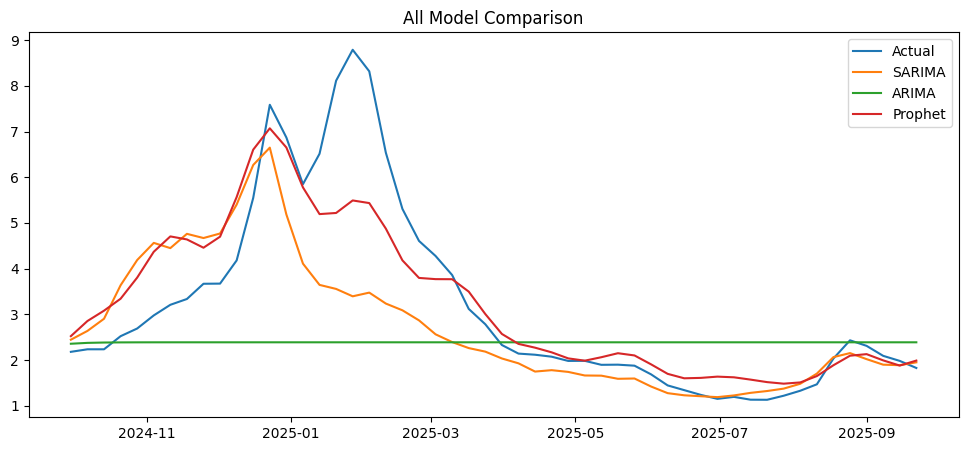

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(dis_df.index, dis_df['Actual'], label='Actual')
plt.plot(dis_df.index, dis_df['SARIMA'], label='SARIMA')
plt.plot(dis_df.index, dis_df['ARIMA'], label='ARIMA')
plt.plot(dis_df.index, dis_df['Prophet'], label='Prophet')

plt.legend()
plt.title("All Model Comparison")
plt.show()

In [ ]:
dis_df['SARIMA_vs_Prophet'] = abs(dis_df['SARIMA'] - dis_df['Prophet'])
dis_df['SARIMA_vs_ARIMA'] = abs(dis_df['SARIMA'] - dis_df['ARIMA'])
dis_df['Prophet_vs_ARIMA'] = abs(dis_df['Prophet'] - dis_df['ARIMA'])

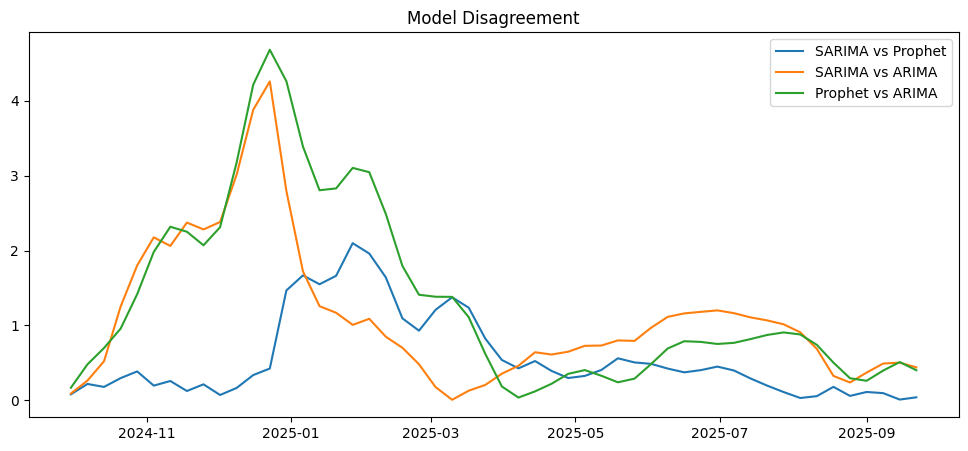

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(dis_df.index, dis_df['SARIMA_vs_Prophet'], label='SARIMA vs Prophet')
plt.plot(dis_df.index, dis_df['SARIMA_vs_ARIMA'], label='SARIMA vs ARIMA')
plt.plot(dis_df.index, dis_df['Prophet_vs_ARIMA'], label='Prophet vs ARIMA')

plt.legend()
plt.title("Model Disagreement")
plt.show()

In [ ]:
rmse_sarima = np.sqrt(mean_squared_error(dis_df['Actual'], dis_df['SARIMA']))
rmse_arima = np.sqrt(mean_squared_error(dis_df['Actual'], dis_df['ARIMA']))
rmse_prophet = np.sqrt(mean_squared_error(dis_df['Actual'], dis_df['Prophet']))

print("SARIMA RMSE:", rmse_sarima)
print("ARIMA RMSE:", rmse_arima)
print("Prophet RMSE:", rmse_prophet)

SARIMA RMSE: 1.5756786200034427
ARIMA RMSE: 2.2190963190622846
Prophet RMSE: 0.9827078697210826


In [ ]:
peak_threshold = dis_df['Actual'].quantile(0.9)

peaks = dis_df[dis_df['Actual'] > peak_threshold]

sarima_peak_error = np.mean(abs(peaks['Actual'] - peaks['SARIMA']))
arima_peak_error = np.mean(abs(peaks['Actual'] - peaks['ARIMA']))
prophet_peak_error = np.mean(abs(peaks['Actual'] - peaks['Prophet']))

print("SARIMA Peak Error:", sarima_peak_error)
print("ARIMA Peak Error:", arima_peak_error)
print("Prophet Peak Error:", prophet_peak_error)

SARIMA Peak Error: 3.4537880673659576
ARIMA Peak Error: 5.3152023553361305
Prophet Peak Error: 1.9119940543947926


In [ ]:
summary = pd.DataFrame({
    'Model': ['SARIMA', 'ARIMA', 'Prophet'],
    'RMSE': [rmse_sarima, rmse_arima, rmse_prophet],
    'Peak Error': [sarima_peak_error, arima_peak_error, prophet_peak_error]
})

summary

,Model,RMSE,Peak Error
0,SARIMA,1.575679,3.453788
1,ARIMA,2.219096,5.315202
2,Prophet,0.982708,1.911994
